# Historical Conditions of Central Region of the California Current

#### This code uses outputs from a 3km ROMS model. Within this code we will be selecting specifically for Gopher rockfish habitat

In [77]:
# required packages for this script
import os
import numpy as np
import pandas as pd
import netCDF4 as nc4
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import calendar

This code averages the oceanographic parameters once for the cells that are filters initially so < 50 meters. It produces a CSV that gives the monthly values of DO, pH, temperature, and CHL-A. Not wind, because wind is selected differently, which is the subsequent the code

In [72]:

# --- Config ---
data_folder = r"D:\Madison"
file_list = sorted([f for f in os.listdir(data_folder) if f.endswith('.nc')])

month_indices = {"Jan":0,"Feb":1,"Mar":2,"Apr":3,"May":4,"Jun":5,"Jul":6,"Aug":7,"Sep":8,"Oct":9,"Nov":10,"Dec":11}
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# Latitude bands (south, north, label, include_north_on_last)
# Latitude bands (south, north, label, include_north_on_last)
bands = [
    (34.45, 41.0, "ALL_41to34p4", True),  # [34.4, 41] inclusive
    (39.0, 41.0, "41to39", False),       # [39,41)
    (37.0, 39.0, "39to37", False),       # [37,39)
    (34.45, 37.0, "37to34p4", True),      # [34.4,37] inclusive top edge
]

def get_2d(ds, names):
    """Return the first 2-D variable in 'names' that exists; else None."""
    for n in names:
        if n in ds.variables:
            v = ds.variables[n]
            if v.ndim == 2:
                return np.array(v)
    return None

# Collect records separately per band
records_by_band = {label: [] for _, _, label, _ in bands}

for file_name in file_list:
    year = int(file_name.split('_')[-1].replace('.nc', ''))
    file_path = os.path.join(data_folder, file_name)

    with nc4.Dataset(file_path) as ds:
        # Expect 3-D (time, y, x)
        do_bot   = np.array(ds.variables["do_bot"])     # (T, Y, X)
        ph_bot   = np.array(ds.variables["ph_bot"])     # (T, Y, X)
        temp_bot = np.array(ds.variables["temp_bot"])   # (T, Y, X)

        # Optional chla/phyto
        chla_all = None
        if "phyto_bot" in ds.variables:
            temp = np.array(ds.variables["phyto_bot"])
            if temp.ndim == 3 and temp.shape[1:] == do_bot.shape[1:]:
                chla_all = temp

        # 2-D latitude & depth on same (Y, X) grid
        lat2d = get_2d(ds, ["lat_rho", "lat", "latitude", "y"])
        if lat2d is None:
            raise KeyError("Couldn't find a 2-D latitude variable (try 'lat_rho', 'lat', or 'latitude').")
        depth2d = get_2d(ds, ["h", "depth", "bathymetry"])
        if depth2d is None:
            # If there's no bathymetry variable, skip depth mask entirely
            depth_mask = np.ones_like(lat2d, dtype=bool)
        else:
            depth_mask = (depth2d <= 50)

    # Replace fill values
    for arr in (do_bot, ph_bot, temp_bot, chla_all):
        if isinstance(arr, np.ndarray):
            arr[arr == -1.0e+34] = np.nan

    # Build latitude band masks (non-overlapping)
    band_masks = {}
    for south, north, label, include_north in bands:
        if include_north:
            band_masks[label] = (lat2d >= south) & (lat2d <= north)   # closed on top
        else:
            band_masks[label] = (lat2d >= south) & (lat2d <  north)   # half-open

    # Loop months
    for month_name, idx in month_indices.items():
        if idx >= do_bot.shape[0]:
            continue

        # Extract monthly 2-D slices
        do_m   = do_bot[idx, :, :] * 0.032
        ph_m   = ph_bot[idx, :, :]
        temp_m = temp_bot[idx, :, :]
        chla_m = chla_all[idx, :, :] if isinstance(chla_all, np.ndarray) else None

        for _, _, label, _ in bands:
            mask = depth_mask & band_masks[label]
            if not np.any(mask):
                rec = {
                    'Year': year, 'Month': month_name,
                    'DO_avg': np.nan, 'DO_sd': np.nan,
                    'pH_avg': np.nan, 'pH_sd': np.nan,
                    'Temperature_avg': np.nan, 'Temperature_sd': np.nan,
                    'Chla_avg': np.nan, 'Chla_sd': np.nan
                }
            else:
                # Apply mask by setting outside cells to NaN, then reduce over all cells
                do_vals   = np.where(mask, do_m,   np.nan)
                ph_vals   = np.where(mask, ph_m,   np.nan)
                temp_vals = np.where(mask, temp_m, np.nan)
                chla_vals = np.where(mask, chla_m, np.nan) if chla_m is not None else None

                rec = {
                    'Year': year, 'Month': month_name,
                    'DO_avg': np.nanmean(do_vals),   'DO_sd': np.nanstd(do_vals),
                    'pH_avg': np.nanmean(ph_vals),   'pH_sd': np.nanstd(ph_vals),
                    'Temperature_avg': np.nanmean(temp_vals), 'Temperature_sd': np.nanstd(temp_vals),
                    'Chla_avg': np.nanmean(chla_vals) if chla_vals is not None else np.nan,
                    'Chla_sd': np.nanstd(chla_vals)  if chla_vals is not None else np.nan
                }

            records_by_band[label].append(rec)

# Build and save one CSV per band
for _, _, label, _ in bands:
    df = pd.DataFrame(records_by_band[label])
    df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
    df.sort_values(['Year', 'Month'], inplace=True)
    out_path = os.path.join(data_folder, f"monthly_averages_allyear_1995_2020_{label}.csv")
    df.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")


Saved: D:\Madison\monthly_averages_allyear_1995_2020_ALL_41to34p4.csv
Saved: D:\Madison\monthly_averages_allyear_1995_2020_41to39.csv
Saved: D:\Madison\monthly_averages_allyear_1995_2020_39to37.csv
Saved: D:\Madison\monthly_averages_allyear_1995_2020_37to34p4.csv


### How many cells in analysis and what is the average depth of those cells?

Looking at how many cells there are and what is the average depth of the cells 

In [49]:
print(f"\n## Year: {year}")

# Annual validity per grid cell (any valid month in that year)
do_any_valid   = np.any(np.isfinite(do_bot), axis=0)
ph_any_valid   = np.any(np.isfinite(ph_bot), axis=0)
temp_any_valid = np.any(np.isfinite(temp_bot), axis=0)
chla_any_valid = np.any(np.isfinite(chla_all), axis=0) if isinstance(chla_all, np.ndarray) else None

for south, north, label, include_north in bands:

    if include_north:
        lat_mask = (lat2d >= south) & (lat2d <= north)
    else:
        lat_mask = (lat2d >= south) & (lat2d < north)

    region_mask = depth_mask & lat_mask

    # Valid masks within region
    do_valid   = region_mask & do_any_valid
    ph_valid   = region_mask & ph_any_valid
    temp_valid = region_mask & temp_any_valid
    chla_valid = region_mask & chla_any_valid if chla_any_valid is not None else None

    # Counts
    do_n   = np.sum(do_valid)
    ph_n   = np.sum(ph_valid)
    temp_n = np.sum(temp_valid)
    chla_n = np.sum(chla_valid) if chla_valid is not None else 0

    # Mean depths
    do_depth_mean   = np.nanmean(depth2d[do_valid])   if do_n   > 0 else np.nan
    ph_depth_mean   = np.nanmean(depth2d[ph_valid])   if ph_n   > 0 else np.nan
    temp_depth_mean = np.nanmean(depth2d[temp_valid]) if temp_n > 0 else np.nan
    chla_depth_mean = np.nanmean(depth2d[chla_valid]) if (chla_valid is not None and chla_n > 0) else np.nan

    # ---- Markdown-style print ----
    print(f"\n### Region: {label}")
    print(f"- Total region cells (depth ≤50m): {np.sum(region_mask)}")
    print(f"- DO cells: {do_n} | Mean depth: {do_depth_mean:.2f} m")
    print(f"- pH cells: {ph_n} | Mean depth: {ph_depth_mean:.2f} m")
    print(f"- Temperature cells: {temp_n} | Mean depth: {temp_depth_mean:.2f} m")
    if chla_any_valid is not None:
        print(f"- Chla cells: {chla_n} | Mean depth: {chla_depth_mean:.2f} m")



## Year: 2020

### Region: ALL_41to34p4
- Total region cells (depth ≤50m): 27931
- DO cells: 434 | Mean depth: 34.34 m
- pH cells: 434 | Mean depth: 34.34 m
- Temperature cells: 434 | Mean depth: 34.34 m
- Chla cells: 434 | Mean depth: 34.34 m

### Region: 41to39
- Total region cells (depth ≤50m): 11052
- DO cells: 107 | Mean depth: 36.34 m
- pH cells: 107 | Mean depth: 36.34 m
- Temperature cells: 107 | Mean depth: 36.34 m
- Chla cells: 107 | Mean depth: 36.34 m

### Region: 39to37
- Total region cells (depth ≤50m): 9044
- DO cells: 206 | Mean depth: 32.74 m
- pH cells: 206 | Mean depth: 32.74 m
- Temperature cells: 206 | Mean depth: 32.74 m
- Chla cells: 206 | Mean depth: 32.74 m

### Region: 37to34p4
- Total region cells (depth ≤50m): 7774
- DO cells: 118 | Mean depth: 35.46 m
- pH cells: 118 | Mean depth: 35.46 m
- Temperature cells: 118 | Mean depth: 35.46 m
- Chla cells: 118 | Mean depth: 35.46 m


### Map portion in figure 2

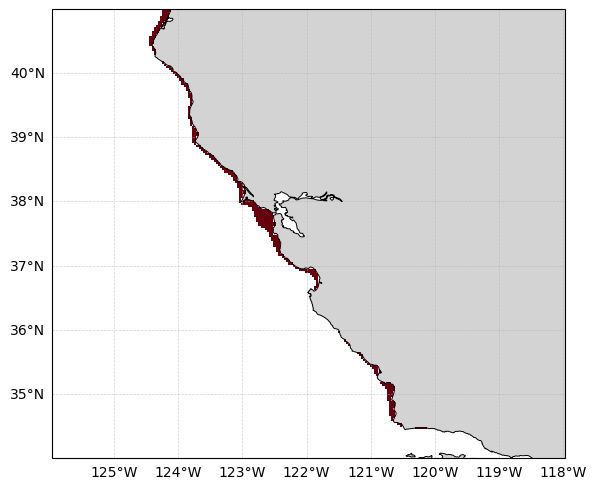

In [52]:
import os
import numpy as np
import netCDF4 as nc4
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---------------------------
# User settings
# ---------------------------
data_folder = r"D:\Madison"
year_to_plot = 2010
month_to_plot = "Jul"
band_to_plot = "ALL_41to34p4"   # or 41to39, 39to37, 37to34p4
var_to_plot = "do_bot"          # not essential if only plotting used cells

month_indices = {
    "Jan":0,"Feb":1,"Mar":2,"Apr":3,"May":4,"Jun":5,
    "Jul":6,"Aug":7,"Sep":8,"Oct":9,"Nov":10,"Dec":11
}

bands = [
    (34.45, 41.0, "ALL_41to34p4", True),
    (39.0, 41.0, "41to39", False),
    (37.0, 39.0, "39to37", False),
    (34.45, 37.0, "37to34p4", True),
]

def get_2d(ds, names):
    for n in names:
        if n in ds.variables:
            v = ds.variables[n]
            if v.ndim == 2:
                return np.array(v)
    return None

# ---------------------------
# Find target file
# ---------------------------
file_list = sorted([f for f in os.listdir(data_folder) if f.endswith(".nc")])

target_file = None
for f in file_list:
    yr = int(f.split("_")[-1].replace(".nc", ""))
    if yr == year_to_plot:
        target_file = os.path.join(data_folder, f)
        break

if target_file is None:
    raise FileNotFoundError(f"No file found for year {year_to_plot}")

# ---------------------------
# Read data
# ---------------------------
with nc4.Dataset(target_file) as ds:
    do_bot = np.array(ds.variables["do_bot"])
    lat2d = get_2d(ds, ["lat_rho", "lat", "latitude", "y"])
    lon2d = get_2d(ds, ["lon_rho", "lon", "longitude", "x"])
    depth2d = get_2d(ds, ["h", "depth", "bathymetry"])

if lat2d is None or lon2d is None:
    raise KeyError("Could not find 2-D latitude/longitude variables")

# replace fill
do_bot[do_bot == -1.0e+34] = np.nan

# depth mask
if depth2d is None:
    depth_mask = np.ones_like(lat2d, dtype=bool)
else:
    depth_mask = (depth2d <= 50)

# latitude band masks
band_masks = {}
for south, north, label, include_north in bands:
    if include_north:
        band_masks[label] = (lat2d >= south) & (lat2d <= north)
    else:
        band_masks[label] = (lat2d >= south) & (lat2d < north)

if band_to_plot not in band_masks:
    raise ValueError(f"band_to_plot must be one of: {list(band_masks.keys())}")

# month slice
idx = month_indices[month_to_plot]
do_m = do_bot[idx, :, :] * 0.032

# final analysis mask:
# depth + latitude band + valid data for chosen month/variable
final_mask = depth_mask & band_masks[band_to_plot] & np.isfinite(do_m)

# turn mask into plottable array
mask_plot = np.where(final_mask, 1.0, np.nan)

# ---------------------------
# Plot
# ---------------------------
fig = plt.figure(figsize=(6, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# map extent
ax.set_extent([
    np.nanmin(lon2d), np.nanmax(lon2d),
    np.nanmin(lat2d), np.nanmax(lat2d)
], crs=ccrs.PlateCarree())

# ocean background stays white by default
ax.set_facecolor("white")

# land
ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none", zorder=1)

# included cells
ax.pcolormesh(
    lon2d, lat2d, mask_plot,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="Reds",
    vmin=0, vmax=1,
    zorder=2
)

# coastline on top
ax.coastlines(resolution="10m", color="black", linewidth=0.7, zorder=3)

# gridlines and labels
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="0.7",
    alpha=0.6,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
plt.savefig("do_coverage_map_no_colorbar.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()



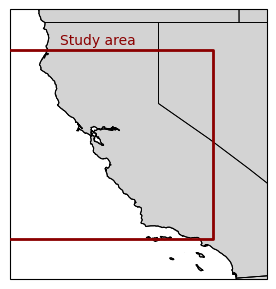

In [53]:


# Use the same study-area bounds as your main map
zoom_lon_min = np.nanmin(lon2d)
zoom_lon_max = np.nanmax(lon2d)
zoom_lat_min = np.nanmin(lat2d)
zoom_lat_max = np.nanmax(lat2d)

fig = plt.figure(figsize=(8, 3))
ax = plt.axes(projection=ccrs.PlateCarree())

# Broad California view
ax.set_extent([-125.5, -116, 32.5, 42.5], crs=ccrs.PlateCarree())

# Background
ax.set_facecolor("white")
ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none", zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
ax.coastlines(resolution="10m", color="black", linewidth=0.8, zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=2)
ax.add_feature(cfeature.STATES, linewidth=0.6, edgecolor="black", zorder=2)

# Draw study-area box
xs = [zoom_lon_min, zoom_lon_max, zoom_lon_max, zoom_lon_min, zoom_lon_min]
ys = [zoom_lat_min, zoom_lat_min, zoom_lat_max, zoom_lat_max, zoom_lat_min]
ax.plot(xs, ys, color="darkred", linewidth=2, transform=ccrs.PlateCarree(), zorder=3)

# Optional label
ax.text(
    zoom_lon_min + 2.3,
    zoom_lat_max + 0.2,
    "Study area",
    color="darkred",
    fontsize=10,
    transform=ccrs.PlateCarree()
)

gl = ax.gridlines(draw_labels=False, linewidth=0, color="0.7", alpha=0.6, linestyle="--")
gl.top_labels = False
gl.right_labels = False
plt.savefig("map.png", dpi=300, bbox_inches='tight', transparent=True)
plt.tight_layout()
plt.show()

#### Now we extract the wind variable

This requires us to make a mask to overlay on the lat and lon to capture 25 km off shore that follows the coast line. 

In [74]:
#testing on one file 
#define a path to the data folder
data_folder = r"D:\Madison"

#make a file path to one of the nc files
test_file_path = os.path.join(data_folder, "ccs3km_rockfish_2006.nc")

#open the file and read all the variables to a 2D numpy grid
ds = nc4.Dataset(test_file_path)
longitude = np.array(ds.variables["lon_rho"])
latitude = np.array(ds.variables["lat_rho"])
do_bot = np.array(ds.variables['do_bot'])
do_srf = np.array(ds.variables['do_srf'])
ph_bot = np.array(ds.variables['ph_bot'])
ph_srf = np.array(ds.variables['ph_srf'])
temp_bot = np.array(ds.variables['temp_bot'])
temp_srf = np.array(ds.variables['temp_srf'])
time = np.array(ds.variables['tmo'])
depth = np.array(ds.variables['h'])
vwind = np.array(ds.variables['Vwind'])
lat_rho = ds.variables["lat_rho"][:]   # 2D array
lon_rho = ds.variables["lon_rho"][:]   # 2D array
mask_rho = ds.variables["mask_rho"][:] # 2D array (1=water, 0=land)

ds.close()

In [75]:

from scipy.spatial import cKDTree

# Flatten lat/lon and mask arrays
lat_flat = lat_rho.flatten()
lon_flat = lon_rho.flatten()
mask_flat = mask_rho.flatten()

# Get coordinates of land and water points
land_coords = np.column_stack((lat_flat[mask_flat == 0], lon_flat[mask_flat == 0]))
water_coords = np.column_stack((lat_flat[mask_flat == 1], lon_flat[mask_flat == 1]))

# Build KD-tree on land coordinates
tree = cKDTree(land_coords)

# Query for nearest land point to each water point
distances_deg, _ = tree.query(water_coords, k=1)

# Convert degrees to km (approx: 1 degree ~ 111 km)
distances_km = distances_deg * 111

# Create distance grid (fill land cells with 0 or nan)
distance_grid_flat = np.full_like(lat_flat, np.nan, dtype=np.float32)
distance_grid_flat[mask_flat == 1] = distances_km
distance_to_coast_km = distance_grid_flat.reshape(lat_rho.shape)

# Create a mask for offshore areas (0 to 25 km from the coast)
offshore_mask = (distance_to_coast_km >= 0) & (distance_to_coast_km <= 10)

# Apply the offshore mask to the vwind data
# This will set vwind values to NaN where the mask is False (i.e., onshore areas)
vwind_masked = np.where(offshore_mask, vwind, np.nan)
vwind_avg = np.nanmean(vwind_masked)

# Ensure it's a normal ndarray, not a MaskedArray
if isinstance(distance_to_coast_km, np.ma.MaskedArray):
    distance_to_coast_km = distance_to_coast_km.filled(np.nan)

np.save("distance_to_coast_km.npy", distance_to_coast_km)

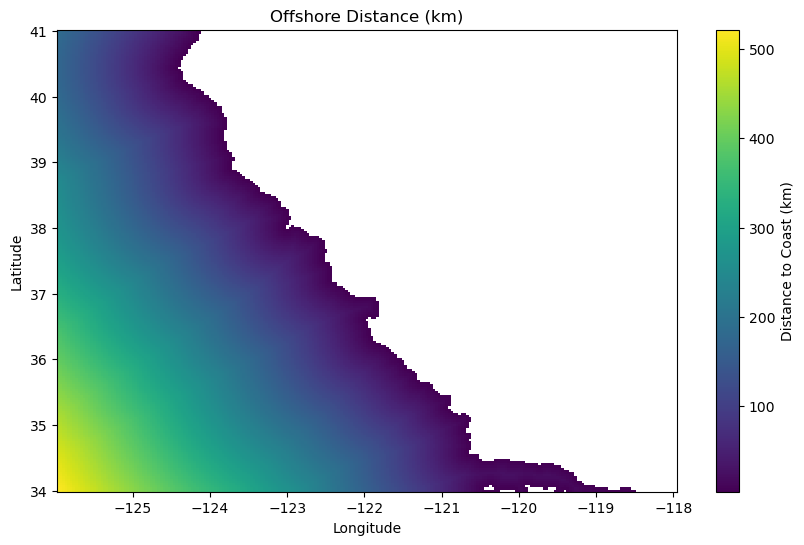

In [63]:
# checking the distance to coast 
plt.figure(figsize=(10, 6))
plt.pcolormesh(lon_rho, lat_rho, distance_to_coast_km, shading='auto', cmap='viridis')
plt.colorbar(label='Distance to Coast (km)')
plt.title('Offshore Distance (km)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

##### Visualization of the mask

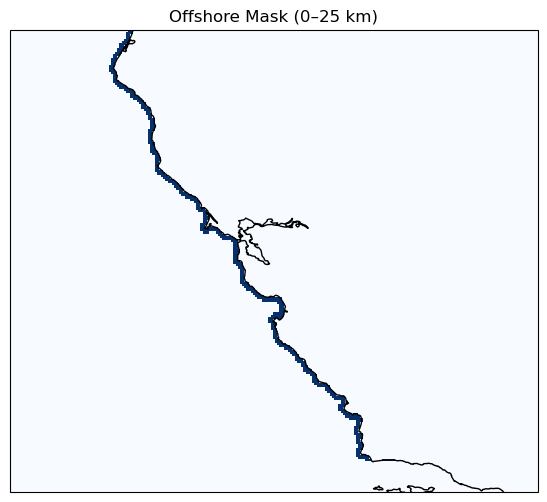

In [67]:
# Create a mask for offshore areas (0 to 100 km from the coast)
offshore_mask = (
    (distance_to_coast_km >= 0) &
    (distance_to_coast_km <= 10) &
    (lat_rho >= 34.45)
)

fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Figure to visualize the offshore mask
# plt.figure(figsize=(10, 6))
plt.pcolormesh(lon_rho, lat_rho, offshore_mask, shading='auto', cmap='Blues')
plt.title("Offshore Mask (0–25 km)") 
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
ax.add_feature(cfeature.LAND, facecolor='lightgray')  # Add land with color
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


Combo map of both wind and boxes 


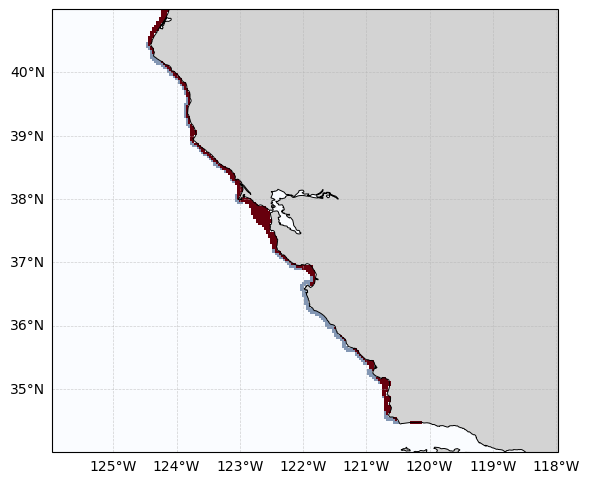

In [68]:
# Plot
# ---------------------------
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# map extent
ax.set_extent([
    np.nanmin(lon2d), np.nanmax(lon2d),
    np.nanmin(lat2d), np.nanmax(lat2d)
], crs=ccrs.PlateCarree())

# ocean background stays white by default
ax.set_facecolor("white")

plt.pcolormesh(lon_rho, lat_rho, offshore_mask, shading='auto', cmap='Blues', alpha=0.5, transform=ccrs.PlateCarree(), zorder=0)

# land
ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none", zorder=1)

# included cells
ax.pcolormesh(
    lon2d, lat2d, mask_plot,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="Reds",
    vmin=0, vmax=1,
    zorder=2
)

# coastline on top
ax.coastlines(resolution="10m", color="black", linewidth=0.7, zorder=3)

# gridlines and labels
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="0.7",
    alpha=0.6,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
plt.savefig("do_coverage_map_no_colorbar.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

### Monthly wind averages

In [78]:

# --- Paths & file list ---
data_folder = r"D:\Madison"
file_list = sorted([f for f in os.listdir(data_folder) if f.endswith('.nc')])

# Offshore mask (same grid as your variables, shape (Y, X))
distance_to_coast_km = np.load("distance_to_coast_km.npy")
offshore_mask = (distance_to_coast_km >= 0) & (distance_to_coast_km <= 10)

# Month name mapping & order
month_names = {i: calendar.month_name[i] for i in range(1, 13)}
month_order = list(calendar.month_name)[1:]  # Jan..Dec

# Latitude bands: (south, north, label, include_north_on_last?)
bands = [
    (34.4, 41.0, "ALL_41to34p4", True),  # [34.4, 41] inclusive
    (39.0, 41.0, "41to39", False),       # [39,41)
    (37.0, 39.0, "39to37", False),       # [37,39)
    (34.4, 37.0, "37to34p4", True),      # [34.4,37] inclusive top edge
]

def get_2d(ds, names):
    """Return first 2-D variable in 'names' if present; else None."""
    for n in names:
        if n in ds.variables and ds.variables[n].ndim == 2:
            return np.array(ds.variables[n])
    return None

def get_fill_value(var):
    fv = getattr(var, "_FillValue", None)
    if fv is None:
        fv = getattr(var, "missing_value", None)
    return fv

# Prepare a dict of results per band
records_by_band = {label: [] for _, _, label, _ in bands}

for file_name in file_list:
    file_path = os.path.join(data_folder, file_name)
    with nc4.Dataset(file_path) as ds:
        # Time
        time_var = ds.variables["tmo"]
        time_vals = time_var[:]
        time_units = getattr(time_var, "units", None)
        time_calendar = getattr(time_var, "calendar", "standard")
        time_datetimes = nc4.num2date(time_vals, units=time_units, calendar=time_calendar)

        # 2-D latitude (Y, X)
        lat2d = get_2d(ds, ["lat_rho", "lat", "latitude"])
        if lat2d is None:
            raise KeyError(f"No 2-D latitude variable ('lat_rho'/'lat'/'latitude') in {file_name}.")

        # Wind variable (3-D: T, Y, X)
        vwind = np.array(ds.variables["Vwind"])
        fv = get_fill_value(ds.variables["Vwind"])
        if fv is None:
            fv = -1.0e34
        vwind = vwind.astype(float, copy=False)
        vwind[vwind == fv] = np.nan

    # Sanity check mask shape
    if offshore_mask.shape != lat2d.shape:
        raise ValueError(f"Mask shape {offshore_mask.shape} != grid {lat2d.shape} in {file_name}")

    # Build latitude band masks
    band_masks = {}
    for south, north, label, include_north in bands:
        if include_north:
            band_masks[label] = (lat2d >= south) & (lat2d <= north)
        else:
            band_masks[label] = (lat2d >= south) & (lat2d <  north)

    # Loop months
    for month_num in range(1, 13):
        idxs = [i for i, dt in enumerate(time_datetimes) if dt.month == month_num]
        if not idxs:
            continue

        vwind_m = vwind[idxs, :, :]  # shape (Nt, Y, X)

        for _, _, label, _ in bands:
            mask = offshore_mask & band_masks[label]
            if not np.any(mask):
                monthly_avg, monthly_sd = np.nan, np.nan
            else:
                # Apply mask (broadcast to time dimension)
                masked = np.where(mask[None, :, :], vwind_m, np.nan)
                monthly_avg = np.nanmean(masked)
                monthly_sd  = np.nanstd(masked)

            year = time_datetimes[idxs[0]].year
            records_by_band[label].append({
                "Year": year,
                "Month": month_names[month_num],
                "Vwind_avg": monthly_avg,
                "Vwind_sd": monthly_sd
            })

# Save one CSV per band
for _, _, label, _ in bands:
    df = pd.DataFrame(records_by_band[label])
    df["Month"] = pd.Categorical(df["Month"], categories=month_order, ordered=True)
    df.sort_values(["Year", "Month"], inplace=True)
    out_path = os.path.join(data_folder, f"monthly_vwind_offshore_averages_{label}.csv")
    df.to_csv(out_path, index=False)
    print(f"Saved to {out_path}")


Saved to D:\Madison\monthly_vwind_offshore_averages_ALL_41to34p4.csv
Saved to D:\Madison\monthly_vwind_offshore_averages_41to39.csv
Saved to D:\Madison\monthly_vwind_offshore_averages_39to37.csv
Saved to D:\Madison\monthly_vwind_offshore_averages_37to34p4.csv


### Calculating wind with both u and v component 

In [81]:
import os
import calendar
import numpy as np
import pandas as pd
import netCDF4 as nc4

# --- Paths & file list ---
data_folder = r"D:\Madison"
file_list = sorted([f for f in os.listdir(data_folder) if f.endswith('.nc')])

# Offshore mask (same grid as your variables, shape (Y, X))
distance_to_coast_km = np.load("distance_to_coast_km.npy")
offshore_mask = (distance_to_coast_km >= 0) & (distance_to_coast_km <= 75)

# Month name mapping & order
month_names = {i: calendar.month_name[i] for i in range(1, 13)}
month_order = list(calendar.month_name)[1:]  # Jan..Dec

# Latitude bands: (south, north, label, include_north_on_last?)
bands = [
    (34.45, 41.0, "ALL_41to34p4", True),  # [34.4, 41] inclusive
    (39.0, 41.0, "41to39", False),       # [39,41)
    (37.0, 39.0, "39to37", False),       # [37,39)
    (34.45, 37.0, "37to34p4", True),      # [34.4,37] inclusive top edge
]

# --------------------------------------------------
# FIXED COASTLINE ANGLE
# --------------------------------------------------
# Angle of coastline measured counterclockwise from east.
# Examples:
#   90 deg  = perfectly north-south coastline
#   105 deg = coastline tilted NW-SE a bit
#   110 deg = a bit more realistic for parts of CCS
#
# Start with 105 or 110 and adjust if needed.
coast_angle_deg = 105.0
theta = np.deg2rad(coast_angle_deg)

# Unit vector pointing poleward along the coastline
tx = np.cos(theta)
ty = np.sin(theta)

def get_2d(ds, names):
    """Return first 2-D variable in 'names' if present; else None."""
    for n in names:
        if n in ds.variables and ds.variables[n].ndim == 2:
            return np.array(ds.variables[n])
    return None

def get_fill_value(var):
    fv = getattr(var, "_FillValue", None)
    if fv is None:
        fv = getattr(var, "missing_value", None)
    return fv

def load_and_clean_3d(ds, var_name):
    """Load 3-D variable (T,Y,X), convert fill values to NaN."""
    arr = np.array(ds.variables[var_name]).astype(float, copy=False)
    fv = get_fill_value(ds.variables[var_name])
    if fv is not None:
        arr[arr == fv] = np.nan
    return arr

# Prepare a dict of results per band
records_by_band = {label: [] for _, _, label, _ in bands}

for file_name in file_list:
    file_path = os.path.join(data_folder, file_name)

    with nc4.Dataset(file_path) as ds:
        # Time
        time_var = ds.variables["tmo"]
        time_vals = time_var[:]
        time_units = getattr(time_var, "units", None)
        time_calendar = getattr(time_var, "calendar", "standard")
        time_datetimes = nc4.num2date(time_vals, units=time_units, calendar=time_calendar)

        # 2-D latitude (Y, X)
        lat2d = get_2d(ds, ["lat_rho", "lat", "latitude"])
        if lat2d is None:
            raise KeyError(f"No 2-D latitude variable ('lat_rho'/'lat'/'latitude') in {file_name}.")

        # Wind variables (3-D: T, Y, X)
        uwind = load_and_clean_3d(ds, "Uwind")
        vwind = load_and_clean_3d(ds, "Vwind")

        # Alongshore wind (positive = poleward along chosen coastline angle)
        alongshore_wind = uwind * tx + vwind * ty

        # Upwelling-favorable wind:
        # equatorward winds are favorable in the CCS,
        # so flip sign so positive = upwelling-favorable
        upwell_wind = -alongshore_wind

    # Sanity check mask shape
    if offshore_mask.shape != lat2d.shape:
        raise ValueError(f"Mask shape {offshore_mask.shape} != grid {lat2d.shape} in {file_name}")

    # Build latitude band masks
    band_masks = {}
    for south, north, label, include_north in bands:
        if include_north:
            band_masks[label] = (lat2d >= south) & (lat2d <= north)
        else:
            band_masks[label] = (lat2d >= south) & (lat2d < north)

    # Loop months
    for month_num in range(1, 13):
        idxs = [i for i, dt in enumerate(time_datetimes) if dt.month == month_num]
        if not idxs:
            continue

        upwell_m = upwell_wind[idxs, :, :]  # shape (Nt, Y, X)

        for _, _, label, _ in bands:
            mask = offshore_mask & band_masks[label]

            if not np.any(mask):
                monthly_avg, monthly_sd = np.nan, np.nan
            else:
                masked = np.where(mask[None, :, :], upwell_m, np.nan)
                monthly_avg = np.nanmean(masked)
                monthly_sd = np.nanstd(masked)

            year = time_datetimes[idxs[0]].year
            records_by_band[label].append({
                "Year": year,
                "Month": month_names[month_num],
                "UpwellWind_avg": monthly_avg,
                "UpwellWind_sd": monthly_sd
            })

# Save one CSV per band
for _, _, label, _ in bands:
    df = pd.DataFrame(records_by_band[label])
    df["Month"] = pd.Categorical(df["Month"], categories=month_order, ordered=True)
    df.sort_values(["Year", "Month"], inplace=True)

    out_path = os.path.join(data_folder, f"monthly_upwelling_wind_offshore_averages_{label}.csv")
    df.to_csv(out_path, index=False)
    print(f"Saved to {out_path}")

Saved to D:\Madison\monthly_upwelling_wind_offshore_averages_ALL_41to34p4.csv
Saved to D:\Madison\monthly_upwelling_wind_offshore_averages_41to39.csv
Saved to D:\Madison\monthly_upwelling_wind_offshore_averages_39to37.csv
Saved to D:\Madison\monthly_upwelling_wind_offshore_averages_37to34p4.csv


In [83]:
import os
import calendar
import numpy as np
import pandas as pd
import netCDF4 as nc4

# --- Paths & file list ---
data_folder = r"D:\Madison"
file_list = sorted([f for f in os.listdir(data_folder) if f.endswith('.nc')])

# Offshore mask (same grid as your variables, shape (Y, X))
distance_to_coast_km = np.load("distance_to_coast_km.npy")
offshore_mask = (distance_to_coast_km >= 0) & (distance_to_coast_km <= 25)

# Month name mapping & order
month_names = {i: calendar.month_name[i] for i in range(1, 13)}
month_order = list(calendar.month_name)[1:]  # Jan..Dec

# Latitude bands: (south, north, label, include_north_on_last?)
bands = [
    (34.4, 41.0, "ALL_41to34p4", True),  # [34.4, 41] inclusive
    (39.0, 41.0, "41to39", False),       # [39,41)
    (37.0, 39.0, "39to37", False),       # [37,39)
    (34.4, 37.0, "37to34p4", True),      # [34.4,37] inclusive top edge
]

def get_2d(ds, names):
    """Return first 2-D variable in 'names' if present; else None."""
    for n in names:
        if n in ds.variables and ds.variables[n].ndim == 2:
            return np.array(ds.variables[n])
    return None

def get_fill_value(var):
    fv = getattr(var, "_FillValue", None)
    if fv is None:
        fv = getattr(var, "missing_value", None)
    return fv

def load_and_clean_3d(ds, var_name):
    """Load 3-D variable (T,Y,X), convert fill values to NaN."""
    arr = np.array(ds.variables[var_name]).astype(float, copy=False)
    fv = get_fill_value(ds.variables[var_name])
    if fv is not None:
        arr[arr == fv] = np.nan
    return arr

def compute_local_alongshore_unit_vectors(distance_to_coast_km):
    """
    Compute local alongshore unit vectors from the gradient of distance-to-coast.

    Assumption:
      - grad(distance) points approximately offshore
      - rotating offshore direction by 90 degrees gives alongshore direction

    Returns:
      tx, ty : 2-D arrays of local alongshore unit vector components
               in x (eastward) and y (northward)
    """
    # Gradient in array coordinates: axis 0 = rows (y-like), axis 1 = cols (x-like)
    gy, gx = np.gradient(distance_to_coast_km.astype(float))

    # Offshore unit vector ~ normalized gradient of distance-to-coast
    mag = np.hypot(gx, gy)
    mag[mag == 0] = np.nan

    nx = gx / mag
    ny = gy / mag

    # Rotate offshore vector 90 degrees counterclockwise to get alongshore
    # alongshore option 1:
    tx = -ny
    ty = nx

    # Normalize again for safety
    tmag = np.hypot(tx, ty)
    tmag[tmag == 0] = np.nan
    tx = tx / tmag
    ty = ty / tmag

    return tx, ty

# --------------------------------------------------
# LOCAL COASTLINE ORIENTATION FROM DISTANCE-TO-COAST
# --------------------------------------------------
tx, ty = compute_local_alongshore_unit_vectors(distance_to_coast_km)

# Optional: only keep vectors in/near your offshore band
tx[~np.isfinite(tx)] = np.nan
ty[~np.isfinite(ty)] = np.nan

# Prepare a dict of results per band
records_by_band = {label: [] for _, _, label, _ in bands}

for file_name in file_list:
    file_path = os.path.join(data_folder, file_name)

    with nc4.Dataset(file_path) as ds:
        # Time
        time_var = ds.variables["tmo"]
        time_vals = time_var[:]
        time_units = getattr(time_var, "units", None)
        time_calendar = getattr(time_var, "calendar", "standard")
        time_datetimes = nc4.num2date(time_vals, units=time_units, calendar=time_calendar)

        # 2-D latitude (Y, X)
        lat2d = get_2d(ds, ["lat_rho", "lat", "latitude"])
        if lat2d is None:
            raise KeyError(f"No 2-D latitude variable ('lat_rho'/'lat'/'latitude') in {file_name}.")

        # Wind variables (3-D: T, Y, X)
        uwind = load_and_clean_3d(ds, "Uwind")
        vwind = load_and_clean_3d(ds, "Vwind")

        # Sanity checks
        if offshore_mask.shape != lat2d.shape:
            raise ValueError(f"Mask shape {offshore_mask.shape} != grid {lat2d.shape} in {file_name}")
        if tx.shape != lat2d.shape or ty.shape != lat2d.shape:
            raise ValueError(f"Alongshore vector shape mismatch in {file_name}")

        # Local alongshore wind
        # positive = one alongshore direction, negative = the opposite
        alongshore_wind = uwind * tx[None, :, :] + vwind * ty[None, :, :]

        # We want positive = equatorward = upwelling-favorable
        # Since the tangent direction from the gradient could point either northward
        # or southward depending on rotation/sign convention, we fix the sign using ty:
        # if ty > 0, tangent has northward component, so equatorward is negative alongshore
        # if ty < 0, tangent has southward component, so equatorward is positive alongshore
        sign_equatorward_positive = np.where(ty >= 0, -1.0, 1.0)

        upwell_wind = alongshore_wind * sign_equatorward_positive[None, :, :]

    # Build latitude band masks
    band_masks = {}
    for south, north, label, include_north in bands:
        if include_north:
            band_masks[label] = (lat2d >= south) & (lat2d <= north)
        else:
            band_masks[label] = (lat2d >= south) & (lat2d < north)

    # Loop months
    for month_num in range(1, 13):
        idxs = [i for i, dt in enumerate(time_datetimes) if dt.month == month_num]
        if not idxs:
            continue

        upwell_m = upwell_wind[idxs, :, :]  # shape (Nt, Y, X)

        for _, _, label, _ in bands:
            mask = offshore_mask & band_masks[label] & np.isfinite(tx) & np.isfinite(ty)

            if not np.any(mask):
                monthly_avg, monthly_sd = np.nan, np.nan
            else:
                masked = np.where(mask[None, :, :], upwell_m, np.nan)
                monthly_avg = np.nanmean(masked)
                monthly_sd = np.nanstd(masked)

            year = time_datetimes[idxs[0]].year
            records_by_band[label].append({
                "Year": year,
                "Month": month_names[month_num],
                "UpwellWind_avg": monthly_avg,
                "UpwellWind_sd": monthly_sd
            })

# Save one CSV per band
for _, _, label, _ in bands:
    df = pd.DataFrame(records_by_band[label])
    df["Month"] = pd.Categorical(df["Month"], categories=month_order, ordered=True)
    df.sort_values(["Year", "Month"], inplace=True)

    out_path = os.path.join(data_folder, f"monthly_upwelling_wind_offshore_averages_{label}.csv")
    df.to_csv(out_path, index=False)
    print(f"Saved to {out_path}")

Saved to D:\Madison\monthly_upwelling_wind_offshore_averages_ALL_41to34p4.csv
Saved to D:\Madison\monthly_upwelling_wind_offshore_averages_41to39.csv
Saved to D:\Madison\monthly_upwelling_wind_offshore_averages_39to37.csv
Saved to D:\Madison\monthly_upwelling_wind_offshore_averages_37to34p4.csv
